In [7]:
import pyearthtools.data
import pyearthtools.pipeline
import warnings
import numpy as np
import site_archive_nci
import xarray as xr
import petextras

In [19]:
sat_accessor = pyearthtools.data.archive.HimawariChannels(bands=['OBS_B01', 'OBS_B02'])

In [20]:
ds = sat_accessor['20201031T06']
ds

<xarray.Dataset> Size: 6GB
Dimensions:                       (time: 6, y: 11000, x: 11000)
Coordinates:
  * time                          (time) datetime64[ns] 48B 2020-10-31T06:00:...
  * x                             (x) float64 88kB -5.5e+06 ... 5.5e+06
  * y                             (y) float64 88kB 5.5e+06 ... -5.5e+06
Data variables:
    channel_0002_scaled_radiance  (time, y, x) float32 3GB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
    geostationary                 (time) float32 24B 9.969e+36 ... 9.969e+36
    scan_line_time                (time, y) datetime64[ns] 528kB dask.array<chunksize=(1, 11000), meta=np.ndarray>
    channel_0001_scaled_radiance  (time, y, x) float32 3GB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
Attributes: (12/53)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    acknowledgment:                  See disclaimer
    cdm_data_type:                   grid
    comment:                         AGLS observations geometry product
    contributor_name:                Commonwealth of Australia, Bureau of Met...
    ...                              ...
    platform:                        Himawari-8
    platform_launch_date:            20141007T051600Z
    wmo_platform_name:               Himawari-8
    wmo_satellite_number:            173
    NCO:                             netCDF Operators version 4.7.7 (Homepage...
    product_version:                 1.0

In [21]:
rad_accessor = pyearthtools.data.archive.hail(radar_id=66)
ds = rad_accessor['20201031T0600']

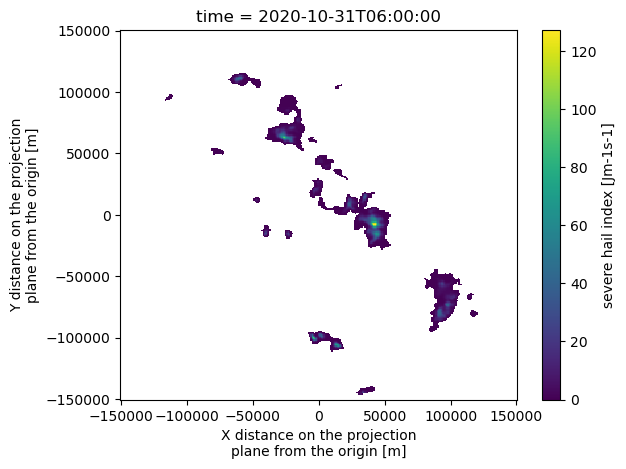

In [18]:
ds.shi.plot()

In [22]:
pipe = pyearthtools.pipeline.Pipeline(
    (sat_accessor,rad_accessor)
)

In [24]:
pipe['20201031T0600']

(<xarray.Dataset> Size: 968MB
 Dimensions:                       (time: 1, y: 11000, x: 11000)
 Coordinates:
   * time                          (time) datetime64[ns] 8B 2020-10-31T06:00:00
   * x                             (x) float64 88kB -5.5e+06 ... 5.5e+06
   * y                             (y) float64 88kB 5.5e+06 ... -5.5e+06
 Data variables:
     channel_0001_scaled_radiance  (time, y, x) float32 484MB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
     geostationary                 (time) float32 4B 9.969e+36
     scan_line_time                (time, y) datetime64[ns] 88kB dask.array<chunksize=(1, 11000), meta=np.ndarray>
     channel_0002_scaled_radiance  (time, y, x) float32 484MB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
 Attributes: (12/56)
     Conventions:                     CF-1.6
     Metadata_Conventions:            Unidata Dataset Discovery v1.0
     acknowledgment:                  See disclaimer
     cdm_data_type:                   grid
   

In [29]:
pipe = pyearthtools.pipeline.Pipeline(
    rad_accessor,
    pyearthtools.pipeline.operations.xarray.normalisation.SingleValueDivision(60)
)

'shi': 60

xr.Dataset(
    'shi': lat, lon -> factor
)

In [28]:
import pyearthtools.pipeline.operations.xarray.normalisation

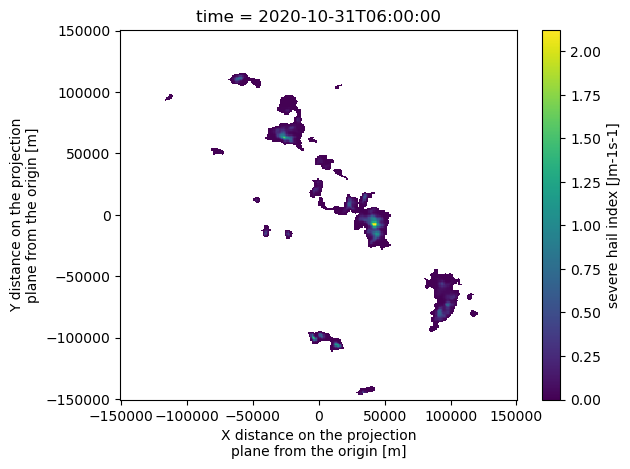

In [35]:
pipe['20201031T0600'].shi.plot()

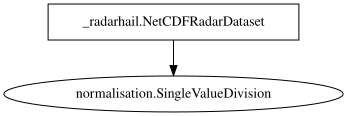

In [33]:
pipe